In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/social_media_engagement.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


# **Data Size**

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset size:", df.size)

Number of rows: 5000
Number of columns: 20
Dataset size: 100000


# **Column Names**

In [ ]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']


# **First 10 Data Set**

In [ ]:
df.head(10)

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,1/1/2024 1:42,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16.0,985,Positive,Macro,True,False
1,POST_02171,1/1/2024 5:05,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9.0,627,Negative,Macro,False,True
2,POST_00210,1/1/2024 9:18,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27.0,79,Positive,Macro,True,True
3,POST_01548,1/1/2024 10:58,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17.0,554,Neutral,Macro,True,False
4,POST_01350,1/1/2024 13:12,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5.0,1136,Positive,Mid-tier,True,False
5,POST_01582,1/2/2024 1:24,Twitter,Poll,Sports,3767,83,522,59434,242,421886,1.04,1,Tuesday,19.0,1611,Negative,Macro,True,False
6,POST_02656,1/2/2024 3:01,Twitter,Poll,Lifestyle,1558,71,676,45929,92,259275,0.89,3,Tuesday,25.0,1406,Negative,Macro,True,False
7,POST_00196,1/2/2024 16:59,Twitter,Thread,Education,599,222,787,68904,314,30966,5.19,16,Tuesday,1.0,399,Negative,Micro,True,False
8,POST_00749,1/2/2024 19:22,YouTube,Live,Food,6062,754,540,947740,1640,395761,1.86,19,Tuesday,22.0,109,Neutral,Macro,False,False
9,POST_03049,1/2/2024 20:04,Twitter,Thread,Travel,597,22,339,67556,74,478824,0.20,20,Tuesday,22.0,1445,Neutral,Macro,True,True


# **Data Types**



In [ ]:
print(df.dtypes)

Post_ID             object
Timestamp           object
Platform            object
Content_Type        object
Category            object
Likes                int64
Comments             int64
Shares               int64
Views                int64
Saves                int64
Follower_Count       int64
Engagement_Rate    float64
Hour_of_Day          int64
Day_of_Week         object
Hashtag_Count      float64
Content_Length       int64
Sentiment           object
Influencer_Tier     object
Has_Media             bool
Is_Verified           bool
dtype: object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   object 
 1   Timestamp        5000 non-null   object 
 2   Platform         5000 non-null   object 
 3   Content_Type     4983 non-null   object 
 4   Category         4983 non-null   object 
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   object 
 14  Hashtag_Count    4984 non-null   float64
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   object 
 17  Influencer_Tie

# **Null Value or Missing Value**


In [ ]:
null_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

null_summary

,Missing_Count,Missing_Percentage
Post_ID,0,0.00
Timestamp,0,0.00
Platform,0,0.00
Content_Type,17,0.34
Category,17,0.34
Likes,0,0.00
Comments,0,0.00
Shares,0,0.00
Views,0,0.00
Saves,0,0.00


# **Unique Value and Multi Value**

In [ ]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

unique_multi_summary = []

for col in categorical_cols:
    # Unique values
    unique_count = df[col].nunique(dropna=True)

    # Possible multi-value cells
    non_null = df[col].dropna().astype(str)

    multi_count = non_null.str.contains(
        r",|;|\|",
        regex=True
    ).sum()

    # Percentage of possible multi-value cells
    multi_percentage = (multi_count / len(non_null) * 100) if len(non_null) > 0 else 0

    unique_multi_summary.append({
        "Column": col,
        "Unique Values": unique_count,
        "Possible Multi-Value": multi_count,
        "Multi-Value %": round(multi_percentage, 2)
    })

unique_multi_df = pd.DataFrame(unique_multi_summary)

unique_multi_df

,Column,Unique Values,Possible Multi-Value,Multi-Value %
0,Post_ID,5000,0,0.0
1,Timestamp,4985,0,0.0
2,Platform,6,0,0.0
3,Content_Type,17,0,0.0
4,Category,12,0,0.0
5,Day_of_Week,7,0,0.0
6,Sentiment,3,0,0.0
7,Influencer_Tier,4,0,0.0


# **Duplication Check**

In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 0


# **Invalid Check**

In [ ]:
print("Invalid Hour:",
      ((df['Hour_of_Day'] < 0) | (df['Hour_of_Day'] > 23)).sum())

Invalid Hour: 0


# **Numerical Distribution or Statistical Analysis**





In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Likes,5000.0,7536.838400,10169.129568,18.00,1707.75,4073.5,7783.000,49949.00
Comments,5000.0,339.898800,399.813585,1.00,96.00,212.0,377.000,1999.00
Shares,5000.0,835.233400,1013.769853,2.00,177.00,427.5,1111.500,4997.00
Views,5000.0,110968.397000,181287.350216,527.00,18506.75,40663.5,84226.750,999256.00
Saves,5000.0,753.150600,932.653475,5.00,200.00,424.0,805.000,4985.00
Follower_Count,5000.0,249959.204000,144592.908235,543.00,124560.25,248930.5,374697.500,499815.00
Engagement_Rate,5000.0,11.960148,71.462053,0.05,1.03,2.3,6.245,3510.46
Hour_of_Day,5000.0,11.562600,6.946577,0.00,5.00,12.0,18.000,23.00
Hashtag_Count,4984.0,14.756220,8.666529,0.00,7.00,15.0,22.000,29.00
Content_Length,5000.0,754.508400,576.334039,15.00,280.00,549.0,1226.250,1999.00


# **Skewness Analysis**




In [ ]:
print("SKEWNESS ANALYSIS")
print("="*60)

skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness_df = pd.DataFrame({
    'Column': skewness.index,
    'Skewness': skewness.values,
    'Level': [
        'Highly Positive' if x > 1
        else 'Positive' if x > 0.5
        else 'Symmetric' if -0.5 <= x <= 0.5
        else 'Negative' if x < -0.5
        else 'Highly Negative' for x in skewness.values
    ]
})
display(skewness_df)

SKEWNESS ANALYSIS


,Column,Skewness,Level
0,Engagement_Rate,28.723193,Highly Positive
1,Views,2.625045,Highly Positive
2,Likes,2.466901,Highly Positive
3,Saves,2.272679,Highly Positive
4,Comments,2.250447,Highly Positive
5,Shares,2.053308,Highly Positive
6,Content_Length,0.649604,Positive
7,Hour_of_Day,-0.005561,Symmetric
8,Follower_Count,-0.017560,Symmetric
9,Hashtag_Count,-0.030714,Symmetric


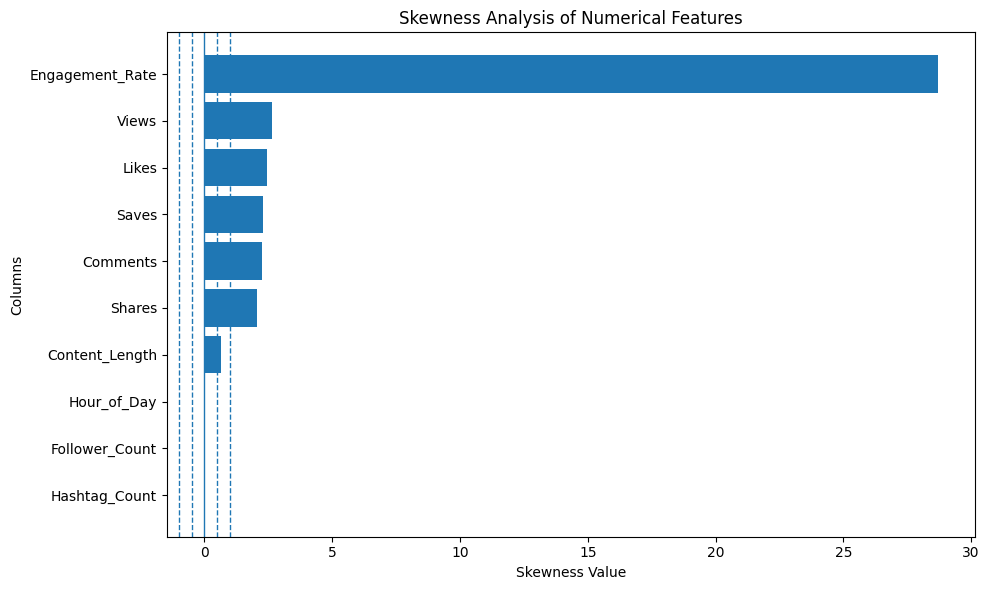

In [ ]:
import matplotlib.pyplot as plt

# Sort for better visualization
plot_df = skewness_df.sort_values('Skewness', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(plot_df['Column'], plot_df['Skewness'])

# Reference lines
plt.axvline(x=0, linewidth=1)
plt.axvline(x=0.5, linestyle='--', linewidth=1)
plt.axvline(x=1, linestyle='--', linewidth=1)
plt.axvline(x=-0.5, linestyle='--', linewidth=1)
plt.axvline(x=-1, linestyle='--', linewidth=1)

plt.xlabel('Skewness Value')
plt.ylabel('Columns')
plt.title('Skewness Analysis of Numerical Features')

plt.tight_layout()
plt.show()

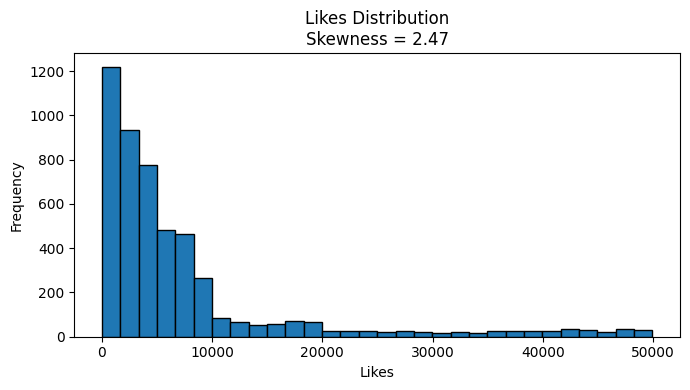

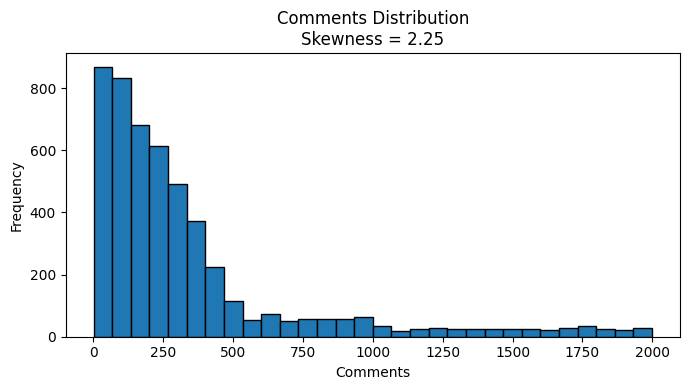

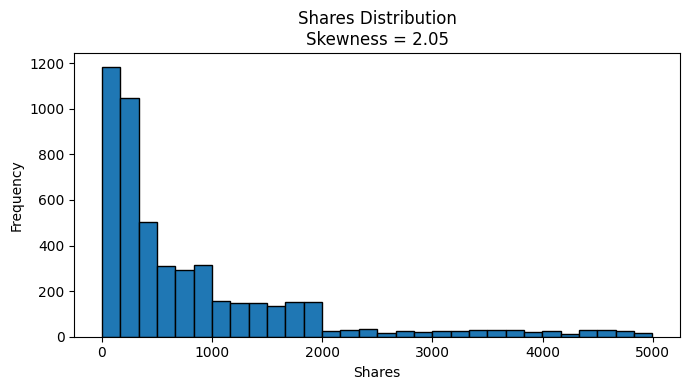

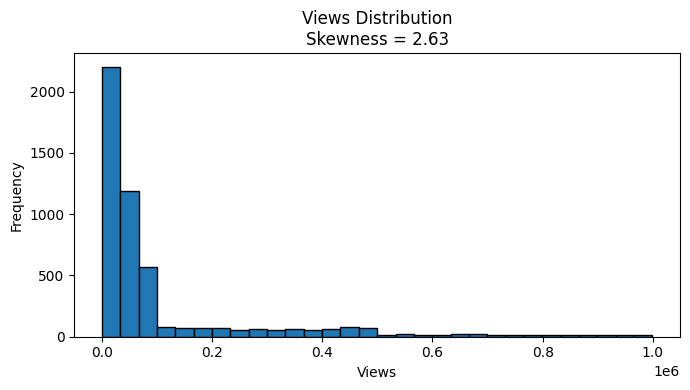

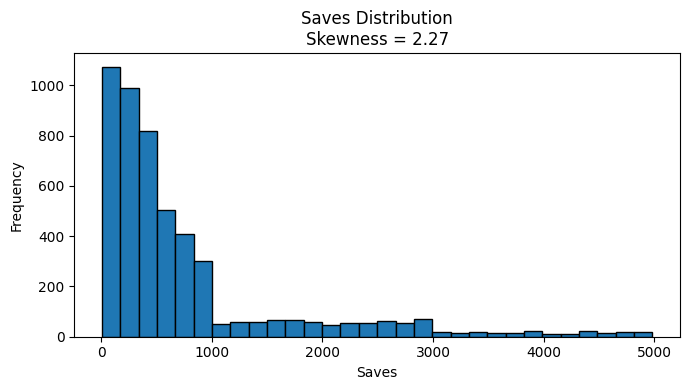

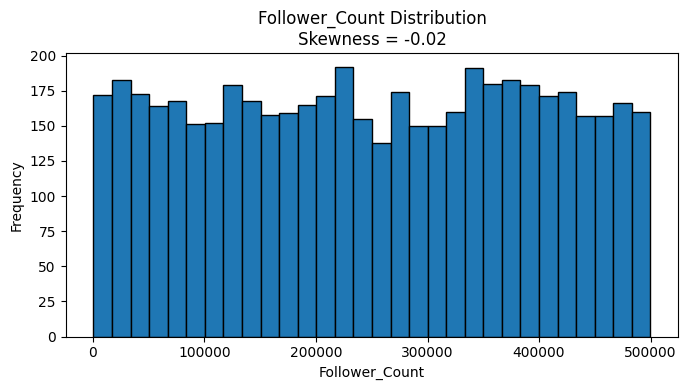

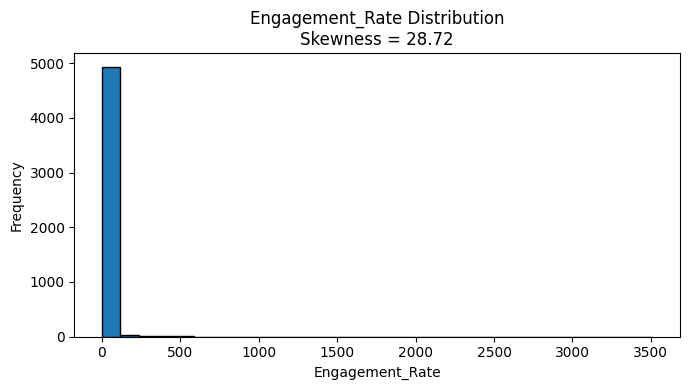

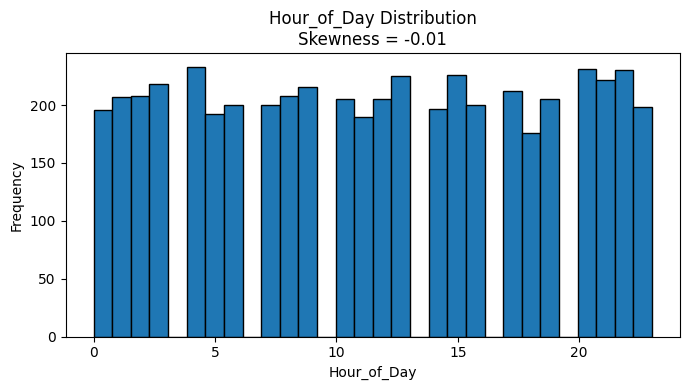

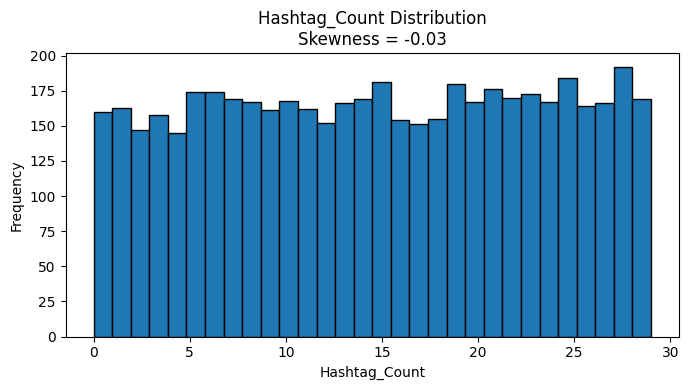

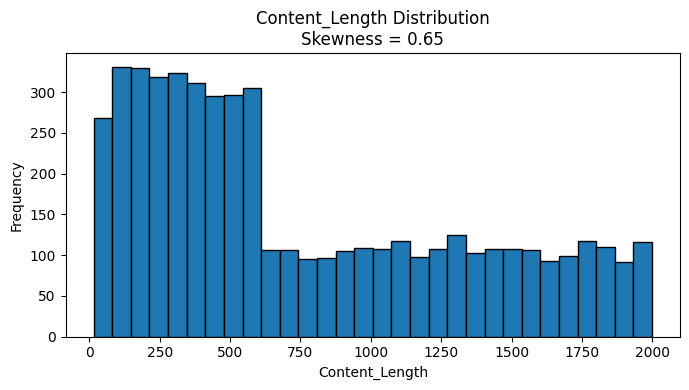

In [ ]:
import matplotlib.pyplot as plt

for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[col].dropna(),
        bins=30,
        edgecolor='black'
    )

    plt.title(
        f'{col} Distribution\nSkewness = {df[col].skew():.2f}'
    )

    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# **Categorical Distribution**

In [ ]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

filtered_categorical_cols = [col for col in categorical_cols if df[col].nunique() <= 50]

for col in filtered_categorical_cols:
    print(f"\n{col}:")
    counts = df[col].value_counts(dropna=False)
    percentages = df[col].value_counts(dropna=False, normalize=True) * 100
    summary_df = pd.DataFrame({
        "Count": counts,
        "Ratio (%)": percentages
    })
    print(summary_df)


Platform:
           Count  Ratio (%)
Platform                   
Instagram   1283      25.66
Twitter      994      19.88
Facebook     984      19.68
TikTok       758      15.16
LinkedIn     502      10.04
YouTube      479       9.58

Content_Type:
                Count  Ratio (%)
Content_Type                    
Video             611      12.22
Story             568      11.36
Poll              380       7.60
Post              377       7.54
Live              356       7.12
Carousel          333       6.66
Photo             319       6.38
Reel              305       6.10
Stitch            258       5.16
Retweet           251       5.02
Duet              248       4.96
Tweet             239       4.78
Thread            235       4.70
Community Post    135       2.70
Document          131       2.62
Short             121       2.42
Article           116       2.32
NaN                17       0.34

Category:
               Count  Ratio (%)
Category                       
Gaming         

ValueError: num must be an integer with 1 <= num <= 6, not 7

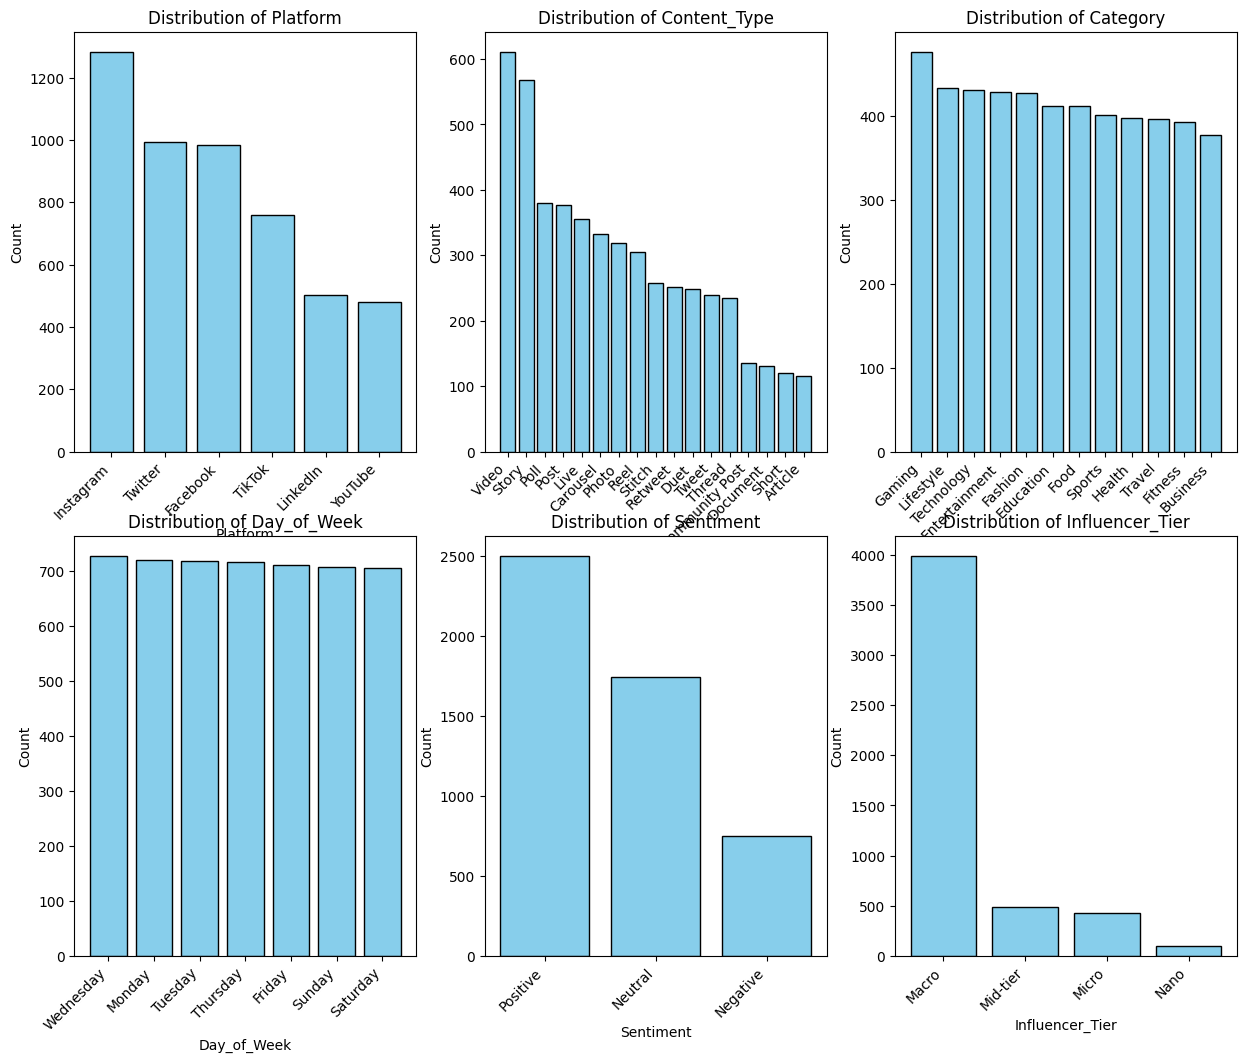

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Categorical Columns
categorical_cols = ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified']

# Bar Chart ဆွဲတယ်
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    value_counts = df[col].value_counts()
    plt.bar(value_counts.index, value_counts.values, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# **Outliers Analysis**

In [ ]:
# ============================================
# COMPLETE OUTLIER DETECTION FOR ALL NUMERICAL COLUMNS
# ============================================

# Define all numerical columns
all_numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("="*60)
print("OUTLIER DETECTION FOR ALL NUMERICAL COLUMNS")
print("="*60)
print(f"\nTotal numerical columns: {len(all_numeric_cols)}")

# Store results
outlier_results = []

for col in all_numeric_cols:
    # Calculate Q1, Q3, IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    # Calculate skewness
    skew_val = df[col].skew()

    # Store results
    outlier_results.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count,
        'Outlier %': round(outlier_percentage, 2),
        'Skewness': round(skew_val, 3),
        'Has Outliers': 'YES' if outlier_count > 0 else 'NO'
    })

# Create DataFrame
outlier_df = pd.DataFrame(outlier_results)

# Sort by outlier percentage (descending)
outlier_df = outlier_df.sort_values('Outlier %', ascending=False)

print(outlier_df.to_string(index=False))

# Count columns with outliers
has_outliers = outlier_df[outlier_df['Outlier Count'] > 0]
no_outliers = outlier_df[outlier_df['Outlier Count'] == 0]


OUTLIER DETECTION FOR ALL NUMERICAL COLUMNS

Total numerical columns: 10
         Column        Q1         Q3        IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %  Skewness Has Outliers
          Views  18506.75  84226.750  65720.000  -80073.2500  182806.7500            855      17.10     2.625          YES
          Saves    200.00    805.000    605.000    -707.5000    1712.5000            658      13.16     2.273          YES
Engagement_Rate      1.03      6.245      5.215      -6.7925      14.0675            609      12.18    28.723          YES
          Likes   1707.75   7783.000   6075.250   -7405.1250   16895.8750            592      11.84     2.467          YES
       Comments     96.00    377.000    281.000    -325.5000     798.5000            564      11.28     2.250          YES
         Shares    177.00   1111.500    934.500   -1224.7500    2513.2500            367       7.34     2.053          YES
 Follower_Count 124560.25 374697.500 250137.250 -250645.6250  7499

# **Outlier Visualization using Box Plots**

Box plots are a great way to visualize the distribution of numerical data and identify outliers. Outliers are typically shown as individual points beyond the 'whiskers' of the box plot, which represent the data range within 1.5 times the Interquartile Range (IQR) from the quartiles.

Let's visualize the columns that had identified outliers:
*   Likes
*   Comments
*   Shares
*   Views
*   Saves
*   Engagement_Rate

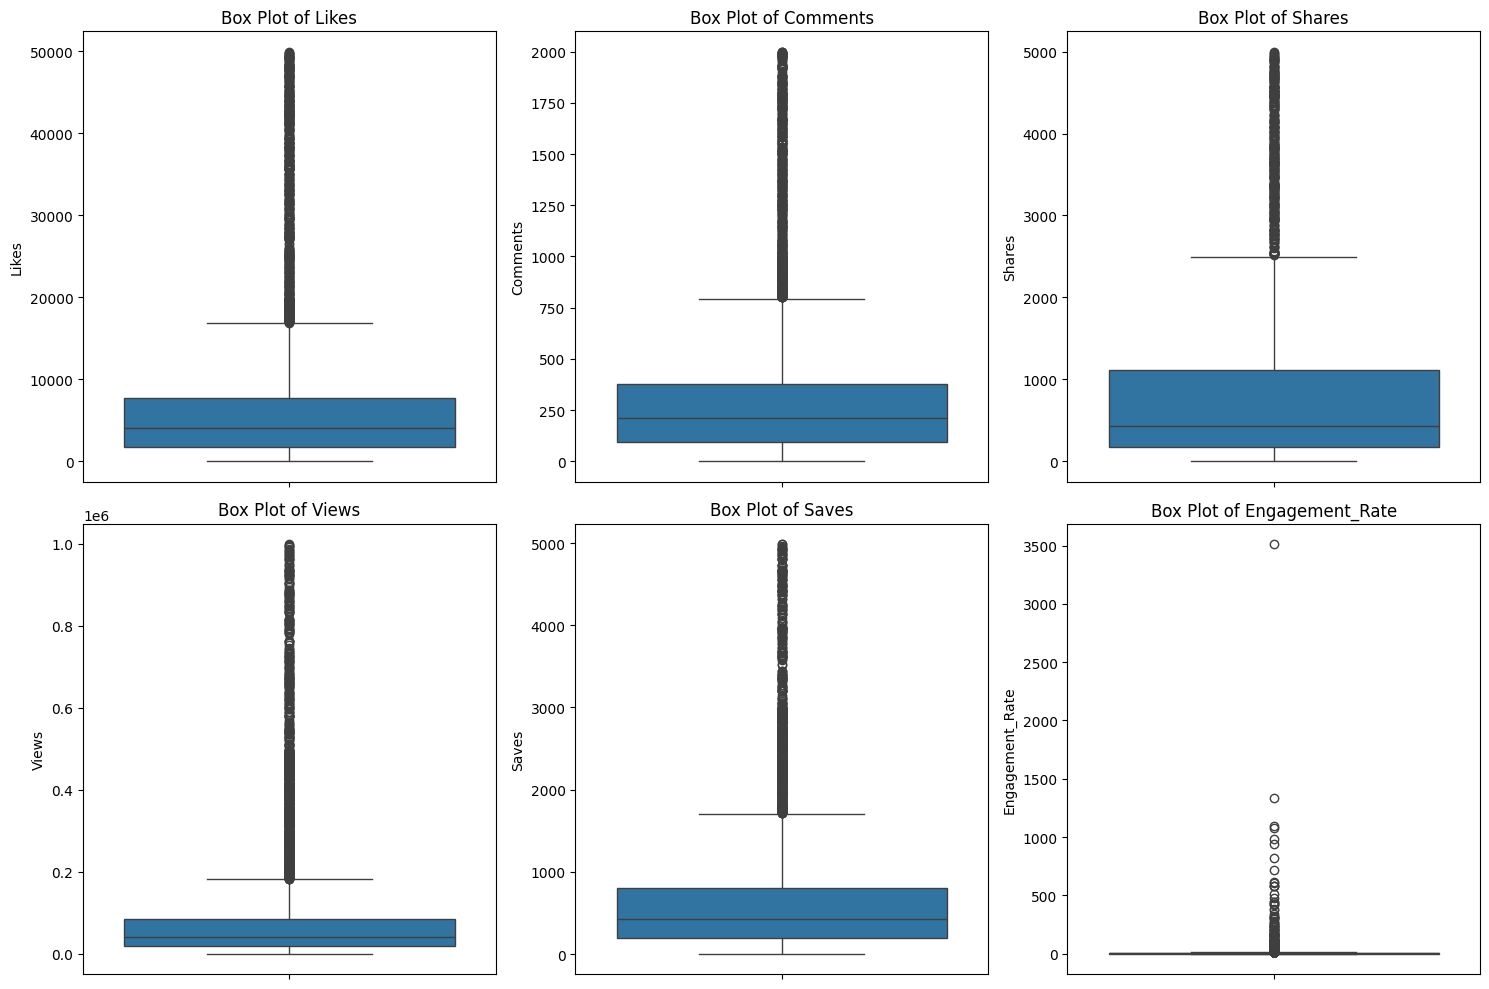

In [ ]:
outlier_cols = ['Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Engagement_Rate']

plt.figure(figsize=(15, 10))
for i, col in enumerate(outlier_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## **Correlation Analysis**

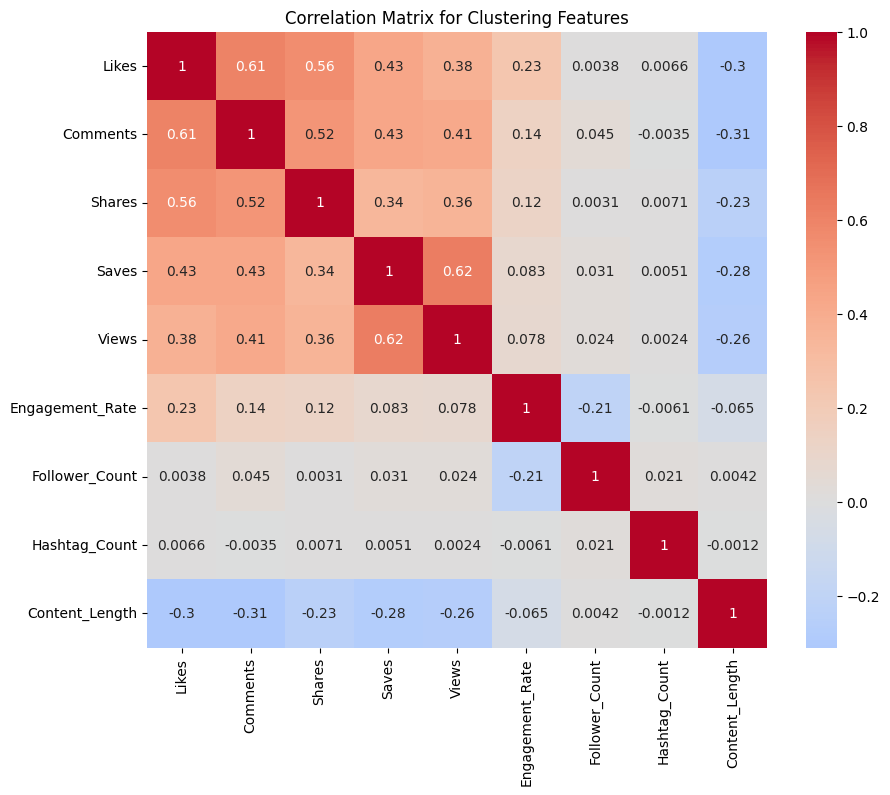

High Correlation Pairs (>0.7):


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Clustering အတွက် Features
clustering_features = ['Likes', 'Comments', 'Shares', 'Saves', 'Views',
                       'Engagement_Rate', 'Follower_Count', 'Hashtag_Count',
                       'Content_Length']

# Correlation Matrix
corr_matrix = df[clustering_features].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# ဆက်စပ်မှုမြင့်တဲ့ Features တွေကို ရှာတယ်
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j],
                                   corr_matrix.iloc[i, j]))

print("High Correlation Pairs (>0.7):")
for pair in high_corr_pairs:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

# **DATA PREPROCESSING**

In [ ]:
import os
import pandas as pd
import numpy as np

# ============================================================
# DATA PREPROCESSING
# ============================================================

# 1. Preserve Raw Dataset
df_old = df.copy()
df_new = df.copy()

# 2. Handle Missing Values
df_new['Content_Type'] = df_new['Content_Type'].fillna(
    df_new['Content_Type'].mode()[0]
)

df_new['Category'] = df_new['Category'].fillna(
    df_new['Category'].mode()[0]
)

df_new['Hashtag_Count'] = df_new['Hashtag_Count'].fillna(
    df_new['Hashtag_Count'].median()
)

# 3. Feature Engineering: Time_Period
def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_new['Time_Period'] = df_new['Hour_of_Day'].apply(get_time_period)

# 4. Create Classification Target
median_val = df_new['Engagement_Rate'].median()

df_new['Engagement_Class'] = (
    df_new['Engagement_Rate'] >= median_val
).astype(int)

# 5. Drop Identifier Columns
df_new = df_new.drop(
    columns=['Post_ID', 'Timestamp'],
    errors='ignore'
)

# 6. Save Cleaned Dataset
df_old.to_csv(
    '/content/old_social_media_engagement_raw.csv',
    index=False
)

df_new.to_csv(
    '/content/new_social_media_engagement_cleaned.csv',
    index=False
)

# Verification
print("=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)
print("Raw dataset shape:", df_old.shape)
print("Cleaned dataset shape:", df_new.shape)
print("Remaining missing values:", df_new.isnull().sum().sum())

display(df_new.head())

PREPROCESSING COMPLETE
Raw dataset shape: (5000, 20)
Cleaned dataset shape: (5000, 20)
Remaining missing values: 0


,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified,Time_Period,Engagement_Class
0,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16.0,985,Positive,Macro,True,False,Night,1
1,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9.0,627,Negative,Macro,False,True,Morning,0
2,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27.0,79,Positive,Macro,True,True,Morning,0
3,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17.0,554,Neutral,Macro,True,False,Morning,0
4,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5.0,1136,Positive,Mid-tier,True,False,Afternoon,1


In [ ]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 9.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2114454 sha256=453b82ca329c409ee89dfcd447b05d6349415443572242579b17558011903cd8
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra


# **Calculation of K Value**

In [ ]:
# ============================================================
# STEP 1: EMPIRICAL EVIDENCE OF K = 2 OVER-COMPRESSION
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn_extra.cluster import KMedoids

# Load dataset and prepare clustering features
df = pd.read_csv('/content/new_social_media_engagement_cleaned.csv')
cluster_cols = ['Likes', 'Comments', 'Shares', 'Views', 'Saves']
X_cluster = df[cluster_cols].copy()
X_cluster_scaled = RobustScaler().fit_transform(np.log1p(X_cluster))

# Fit K-Medoids with K = 2
km2 = KMedoids(n_clusters=2, metric='manhattan', init='k-medoids++', random_state=42)
df['Cluster_K2'] = km2.fit_predict(X_cluster_scaled)

# Ensure proper sorting by Views (Cluster 0: Low, Cluster 1: High)
order_k2 = df.groupby('Cluster_K2')['Views'].mean().sort_values().index.tolist()
label_map_k2 = {order_k2[0]: 'Cluster_0 (Low/Baseline)', order_k2[1]: 'Cluster_1 (Viral Outliers)'}
df['Cluster_K2_Label'] = df['Cluster_K2'].map(label_map_k2)

# Compute Distribution and Engagement Profiles
size_k2 = df['Cluster_K2_Label'].value_counts().reset_index()
size_k2.columns = ['Cluster Partition', 'Tuple Count']
size_k2['Percentage'] = (size_k2['Tuple Count'] / len(df) * 100).round(2).astype(str) + '%'

profile_k2 = df.groupby('Cluster_K2_Label')[cluster_cols].mean()

print("=" * 75)
print("EMPIRICAL DEFECT OF K = 2: SEVERE SKEWNESS & OVER-COMPRESSION")
print("=" * 75)
print("\n1. Class Distribution Imbalance:")
display(size_k2)

print("\n2. Mean Interaction Profile Disparity:")
display(profile_k2.round(2))

print(f"\n[Observation] Cluster 0 pools {size_k2.loc[0, 'Percentage']} of all posts, combining failed content")
print(f"with steady-state baseline engagement into an undifferentiated mass.")

EMPIRICAL DEFECT OF K = 2: SEVERE SKEWNESS & OVER-COMPRESSION

1. Class Distribution Imbalance:


,Cluster Partition,Tuple Count,Percentage
0,Cluster_0 (Low/Baseline),3817,76.34%
1,Cluster_1 (Viral Outliers),1183,23.66%



2. Mean Interaction Profile Disparity:


,Likes,Comments,Shares,Views,Saves
Cluster_K2_Label,,,,,
Cluster_0 (Low/Baseline),3578.75,185.25,486.54,37696.98,378.06
Cluster_1 (Viral Outliers),20307.77,838.89,1960.31,347381.76,1963.38



[Observation] Cluster 0 pools 76.34% of all posts, combining failed content
with steady-state baseline engagement into an undifferentiated mass.


In [ ]:
# ============================================================
# STEP 2: MULTI-CRITERIA EVALUATION (MARGINAL GAIN ANALYSIS)
# ============================================================
from sklearn.metrics import silhouette_score, calinski_harabasz_score

k_range = list(range(2, 9))
cost_list, sil_list, ch_list = [], [], []

for k in k_range:
    km = KMedoids(n_clusters=k, metric='manhattan', init='k-medoids++', random_state=42)
    labels = km.fit_predict(X_cluster_scaled)
    cost_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_cluster_scaled, labels, metric='manhattan'))
    ch_list.append(calinski_harabasz_score(X_cluster_scaled, labels))

# Calculate First Difference (Rate of Reduction) & Second Difference (Curvature)
delta1 = -np.diff(cost_list)
delta2 = np.diff(delta1)

eval_rows = []
for i, k in enumerate(k_range):
    d1 = delta1[i-1] if i >= 1 else np.nan
    d2 = delta2[i-2] if i >= 2 else np.nan
    eval_rows.append({
        'K': k,
        'Manhattan Cost': round(cost_list[i], 2),
        'Silhouette': round(sil_list[i], 4),
        'Calinski-Harabasz': round(ch_list[i], 2),
        'Cost Reduction (Δ1)': round(d1, 2) if not np.isnan(d1) else '-',
        'Curvature Acc (Δ2)': round(d2, 2) if not np.isnan(d2) else '-'
    })

eval_df = pd.DataFrame(eval_rows).set_index('K')
print("=" * 80)
print("CLUSTERING EVALUATION MATRIX")
print("=" * 80)
display(eval_df)

CLUSTERING EVALUATION MATRIX


,Manhattan Cost,Silhouette,Calinski-Harabasz,Cost Reduction (Δ1),Curvature Acc (Δ2)
K,,,,,
2,13030.69,0.4247,2937.51,-,-
3,11603.59,0.2546,2086.53,1427.1,-
4,11097.76,0.2109,1663.59,505.83,-921.28
5,10744.24,0.1631,1361.74,353.52,-152.31
6,10258.67,0.1614,1221.77,485.57,132.05
7,9943.98,0.1561,1123.77,314.69,-170.89
8,9913.49,0.1331,1015.82,30.49,-284.19


In [ ]:
# ============================================================
# STEP 3: RESOLUTION PARTITIONING (K = 3) & DYNAMIC RANKING
# ============================================================
final_k = 3
final_km = KMedoids(
    n_clusters=final_k,
    metric='manhattan',
    init='k-medoids++',
    random_state=42
)
df['Cluster'] = final_km.fit_predict(X_cluster_scaled)

# Order clusters by mean Views dynamically
views_order = df.groupby('Cluster')['Views'].mean().sort_values().index.tolist()
tier_mapping = {
    views_order[0]: 'Low_Engagement_Post',
    views_order[1]: 'Moderate_Engagement_Post',
    views_order[2]: 'Viral_Post'
}
df['Cluster_Label'] = df['Cluster'].map(tier_mapping)

print("=" * 75)
print("FINAL THREE-TIER BUSINESS RESOLUTION PROFILES (K = 3)")
print("=" * 75)

# Cluster size breakdown
size_k3 = df['Cluster_Label'].value_counts().reset_index()
size_k3.columns = ['Cluster Tier', 'Tuple Count']
size_k3['Percentage'] = (size_k3['Tuple Count'] / len(df) * 100).round(2).astype(str) + '%'
display(size_k3)

# Engagement profiles across all metrics
print("\nMean Interaction Metrics Profile:")
display(df.groupby('Cluster_Label')[cluster_cols].mean().loc[
    ['Low_Engagement_Post', 'Moderate_Engagement_Post', 'Viral_Post']
].round(2))

# Save output for Chapter 3.1.2 Association Rule Mining
df.to_csv('/content/social_media_with_clusters.csv', index=False)
print("\n[SUCCESS] Clustered dataset saved to '/content/social_media_with_clusters.csv'")

FINAL THREE-TIER BUSINESS RESOLUTION PROFILES (K = 3)


,Cluster Tier,Tuple Count,Percentage
0,Moderate_Engagement_Post,2429,48.58%
1,Low_Engagement_Post,1417,28.34%
2,Viral_Post,1154,23.08%



Mean Interaction Metrics Profile:


,Likes,Comments,Shares,Views,Saves
Cluster_Label,,,,,
Low_Engagement_Post,1774.82,94.66,541.37,31518.71,210.27
Moderate_Engagement_Post,4747.97,240.82,457.63,43026.30,491.76
Viral_Post,20482.20,849.56,1990.86,351533.01,1969.94



[SUCCESS] Clustered dataset saved to '/content/social_media_with_clusters.csv'


# **Feature Checking Befroe Association**

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

features_to_check = [
    'Platform',
    'Content_Type',
    'Category',
    'Sentiment',
    'Influencer_Tier',
    'Day_of_Week',
    'Time_Period',

]

results = []

for feature in features_to_check:

    contingency = pd.crosstab(
        df[feature],
        df['Cluster_Label']
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.values.sum()
    r, k = contingency.shape

    cramer_v = np.sqrt(
        (chi2 / n) / min(k - 1, r - 1)
    )

    results.append({
        'Feature': feature,
        'Chi_Square': chi2,
        'P_Value': p_value,
        'Cramers_V': cramer_v
    })

association_results = pd.DataFrame(results)

association_results = association_results.sort_values(
    'Cramers_V',
    ascending=False
)

display(association_results.round(4))

,Feature,Chi_Square,P_Value,Cramers_V
0,Platform,6267.7327,0.0000,0.7917
1,Content_Type,4643.1859,0.0000,0.6814
2,Category,31.6230,0.0841,0.0562
5,Day_of_Week,11.1515,0.5160,0.0334
4,Influencer_Tier,7.7676,0.2556,0.0279
6,Time_Period,7.1759,0.3049,0.0268
3,Sentiment,4.4655,0.3467,0.0211


# **Association Mining**

---

Feature Selection,
Encoding,
Frequent Pattern

In [ ]:
# ============================================================
# CHAPTER 3.1.2: APRIORI ASSOCIATION RULE MINING
# ============================================================

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Load clustered dataset
df = pd.read_csv('/content/social_media_with_clusters.csv')

# Final selected attributes
association_cols = [
    'Content_Type',
    'Category',
    'Sentiment',
    'Time_Period',
    'Cluster_Label'
]

# One-hot encode transaction basket
basket = pd.get_dummies(
    df[association_cols].astype(str),
    dtype=bool
)

# Mine frequent itemsets
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True,
    max_len=3
)

print("=" * 70)
print("FREQUENT ITEMSET MINING")
print("=" * 70)
print("Basket Shape:", basket.shape)
print("Frequent Itemsets:", len(frequent_itemsets))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

FREQUENT ITEMSET MINING
Basket Shape: (5000, 39)
Frequent Itemsets: 258


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# **Association Rule Generation & Engagement Post Filtering**

In [ ]:
# ============================================================
# ASSOCIATION RULE GENERATION & ENGAGEMENT Post FILTERING
# ============================================================

# Generate rules
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.30
)

cluster_prefix = 'Cluster_Label_'

# Keep only:
# Antecedent (Features) → Consequent (Exactly ONE Engagement Cluster)
target_rules = rules[

    # Consequent must contain exactly one item
    (rules['consequents'].apply(len) == 1)

    &

    # Consequent must be Cluster_Label
    (rules['consequents'].apply(
        lambda x: next(iter(x)).startswith(cluster_prefix)
    ))

    &

    # Antecedent must NOT contain Cluster_Label
    (rules['antecedents'].apply(
        lambda x: not any(
            item.startswith(cluster_prefix)
            for item in x
        )
    ))
].copy()

# Convert frozensets to readable strings for initial filtering
target_rules['antecedents_str'] = target_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
target_rules['consequents_str'] = target_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Define desired consequent labels
desired_consequent_labels = [
    'Cluster_Label_Low_Engagement_Post',
    'Cluster_Label_Moderate_Engagement_Post',
    'Cluster_Label_Viral_Post'
]

# Filter for statistically meaningful non-random associations (Lift >= 1.20)
# and specific consequent labels
meaningful_rules = target_rules[
    (target_rules['lift'] >= 1.20) &
    (target_rules['consequents_str'].isin(desired_consequent_labels))
].sort_values(
    by=['lift', 'confidence'],
    ascending=[False, False]
).reset_index(drop=True)

# Format display table
display_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
rule_table = meaningful_rules[display_cols].rename(columns={
    'antecedents_str': 'Creative Strategy (Antecedent)',
    'consequents_str': 'Engagement Outcome (Consequent)',
    'support': 'Support',
    'confidence': 'Confidence',
    'lift': 'Lift'
})

print("=" * 70)
print("TOP 20 MEANINGFUL ASSOCIATION RULES (Low, Moderate, Viral Outcomes)")
print("=" * 70)
print("Total Meaningful Rules (filtered):", len(meaningful_rules))

# Display top 20 rules in a table
display(rule_table.head(20).round(4))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

TOP 20 MEANINGFUL ASSOCIATION RULES (Low, Moderate, Viral Outcomes)
Total Meaningful Rules (filtered): 31


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Creative Strategy (Antecedent),Engagement Outcome (Consequent),Support,Confidence,Lift
0,Content_Type_Stitch,Cluster_Label_Viral_Post,0.0498,0.9651,4.1816
1,"Content_Type_Stitch, Sentiment_Positive",Cluster_Label_Viral_Post,0.0240,0.9600,4.1594
2,Content_Type_Duet,Cluster_Label_Viral_Post,0.0474,0.9556,4.1406
3,"Content_Type_Duet, Sentiment_Positive",Cluster_Label_Viral_Post,0.0242,0.9528,4.1281
4,Content_Type_Short,Cluster_Label_Viral_Post,0.0216,0.8926,3.8673
5,Content_Type_Community Post,Cluster_Label_Viral_Post,0.0234,0.8667,3.7551
6,Content_Type_Article,Cluster_Label_Low_Engagement_Post,0.0232,1.0000,3.5286
7,Content_Type_Document,Cluster_Label_Low_Engagement_Post,0.0262,1.0000,3.5286
8,"Content_Type_Video, Sentiment_Positive",Cluster_Label_Viral_Post,0.0354,0.5655,2.4502
9,Content_Type_Poll,Cluster_Label_Low_Engagement_Post,0.0494,0.6500,2.2936


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# **For Prediction**

In [ ]:
candidate_features = [
    'Platform',
    'Content_Type',
    'Category',
    'Sentiment',
    'Influencer_Tier',
    'Day_of_Week',
    'Time_Period',
    'Follower_Count',
    'Hashtag_Count',
    'Content_Length'
]

X = df_new[candidate_features].copy()
y = df_new['Engagement_Class']

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("\nTarget Distribution:")
print(y.value_counts())

X Shape: (5000, 10)
y Shape: (5000,)

Target Distribution:
Engagement_Class
1    2501
0    2499
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# **Before Feature Selection**

In [ ]:
# Separate categorical and numerical features
categorical_cols = [
    'Platform',
    'Content_Type',
    'Category',
    'Sentiment',
    'Influencer_Tier',
    'Day_of_Week',
    'Time_Period'
]

numerical_cols = [
    'Follower_Count',
    'Hashtag_Count',
    'Content_Length'
]

# One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False,
    dtype=int
)

print("Before Encoding:", X.shape)
print("After Encoding:", X_encoded.shape)

display(X_encoded.head())

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Before Encoding: (5000, 10)
After Encoding: (5000, 56)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Follower_Count,Hashtag_Count,Content_Length,Platform_Facebook,Platform_Instagram,Platform_LinkedIn,Platform_TikTok,Platform_Twitter,Platform_YouTube,Content_Type_Article,...,Day_of_Week_Monday,Day_of_Week_Saturday,Day_of_Week_Sunday,Day_of_Week_Thursday,Day_of_Week_Tuesday,Day_of_Week_Wednesday,Time_Period_Afternoon,Time_Period_Evening,Time_Period_Morning,Time_Period_Night
0,223080,16.0,985,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,312647,9.0,627,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
2,220737,27.0,79,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
3,428935,17.0,554,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,64384,5.0,1136,0,1,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(
    X_encoded,
    y,
    random_state=42
)

# Create results table
mi_results = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
}).sort_values(
    by='MI_Score',
    ascending=False
)

print("MUTUAL INFORMATION FEATURE SELECTION")
print("=" * 50)

display(mi_results.head(10))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

MUTUAL INFORMATION FEATURE SELECTION


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Feature,MI_Score
0,Follower_Count,0.160650
41,Influencer_Tier_Macro,0.102858
6,Platform_TikTok,0.087542
42,Influencer_Tier_Micro,0.059918
5,Platform_LinkedIn,0.047187
43,Influencer_Tier_Mid-tier,0.034568
13,Content_Type_Duet,0.034304
2,Content_Length,0.034020
21,Content_Type_Stitch,0.031606
7,Platform_Twitter,0.021832


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_encoded, y)

rf_results = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("RANDOM FOREST FEATURE IMPORTANCE")
display(rf_results.head(10))

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

RANDOM FOREST FEATURE IMPORTANCE


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Feature,Importance
0,Follower_Count,0.251135
6,Platform_TikTok,0.090488
2,Content_Length,0.079708
41,Influencer_Tier_Macro,0.062820
1,Hashtag_Count,0.055184
5,Platform_LinkedIn,0.033129
42,Influencer_Tier_Micro,0.028525
8,Platform_YouTube,0.027775
21,Content_Type_Stitch,0.020086
43,Influencer_Tier_Mid-tier,0.020016


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# ============================================================
# COMBINE FEATURE IMPORTANCE BY ORIGINAL FEATURES
# ============================================================

feature_summary = []

for feature in candidate_features:

    # Find all encoded features belonging to this original feature
    mi_score = mi_results[
        mi_results['Feature'].apply(
            lambda x: x == feature or x.startswith(feature + '_')
        )
    ]['MI_Score'].sum()

    rf_score = rf_results[
        rf_results['Feature'].apply(
            lambda x: x == feature or x.startswith(feature + '_')
        )
    ]['Importance'].sum()

    feature_summary.append({
        'Feature': feature,
        'MI_Score': mi_score,
        'RF_Importance': rf_score
    })


feature_summary = pd.DataFrame(feature_summary)

# Normalize scores for fair comparison
feature_summary['MI_Normalized'] = (
    feature_summary['MI_Score'] /
    feature_summary['MI_Score'].max()
)

feature_summary['RF_Normalized'] = (
    feature_summary['RF_Importance'] /
    feature_summary['RF_Importance'].max()
)

# Combined score
feature_summary['Combined_Score'] = (
    feature_summary['MI_Normalized'] +
    feature_summary['RF_Normalized']
) / 2

# Sort final results
feature_summary = feature_summary.sort_values(
    'Combined_Score',
    ascending=False
).reset_index(drop=True)

print("FINAL FEATURE SELECTION RESULTS")
display(feature_summary)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

FINAL FEATURE SELECTION RESULTS


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Feature,MI_Score,RF_Importance,MI_Normalized,RF_Normalized,Combined_Score
0,Follower_Count,0.160650,0.251135,0.797410,1.000000,0.898705
1,Platform,0.181652,0.193502,0.901659,0.770507,0.836083
2,Influencer_Tier,0.201464,0.116444,1.000000,0.463668,0.731834
3,Content_Type,0.123238,0.105819,0.611713,0.421362,0.516537
4,Content_Length,0.034020,0.079708,0.168865,0.317390,0.243127
5,Category,0.004541,0.076497,0.022538,0.304606,0.163572
6,Day_of_Week,0.012281,0.054289,0.060959,0.216174,0.138567
7,Time_Period,0.020055,0.038655,0.099547,0.153920,0.126733
8,Hashtag_Count,0.000000,0.055184,0.000000,0.219739,0.109870
9,Sentiment,0.000437,0.028767,0.002169,0.114549,0.058359


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# **After Feature Selection**

In [2]:
# Cell 1: Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries successfully imported.")

Libraries successfully imported.


# **Selected Features**

In [3]:
# Cell 2: Load cleaned data and prepare selected features
df = pd.read_csv('/content/new_social_media_engagement_cleaned.csv')

# If Engagement_Class is not already present, binarize at the median
if 'Engagement_Class' not in df.columns:
    median_threshold = df['Engagement_Rate'].median()
    df['Engagement_Class'] = (df['Engagement_Rate'] >= median_threshold).astype(int)

# Final 5 selected features (without Follower_Count)
selected_features = [
    'Platform',
    'Content_Type',
    'Content_Length',
    'Category',
    'Time_Period'
]

# Prepare final selected features
X = df[selected_features].copy()
y = df['Engagement_Class'].astype(int).copy()

# Separate feature types
categorical_features = [
    'Platform',
    'Content_Type',
    'Category',
    'Time_Period'
]

numerical_features = [
    'Content_Length'
]

print(f"Total instances: {X.shape[0]}")
print(f"Selected raw features: {X.shape[1]}")

print("\nClass distribution (0 = Low, 1 = High):")
print(y.value_counts(normalize=True).round(4))

Total instances: 5000
Selected raw features: 5

Class distribution (0 = Low, 1 = High):
Engagement_Class
1    0.5002
0    0.4998
Name: proportion, dtype: float64


# **Splitting Train and Test Data**

In [4]:
# Cell 3: Stratified partitioning to preserve class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 4000 samples
Testing set:  1000 samples


# **Creating Preprocessor**

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Leakage-safe preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


# **Initializing Pipeline**

In [6]:
# Cell 4: Initialize and fit 3 model pipelines

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# 1. Logistic Regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ))
])


# 2. Decision Tree
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        random_state=42
    ))
])


# 3. Random Forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])


# Train all models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("All 3 models trained successfully.")

All 3 models trained successfully.


# **10-fold cross validation**

In [ ]:
# Cell 5: 10-fold cross validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_lr = cross_val_score(lr_model, X, y, cv=skf, scoring='accuracy')
cv_dt = cross_val_score(dt_model, X, y, cv=skf, scoring='accuracy')
cv_rf = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')

print("10-Fold Cross-Validation Accuracy (Mean ± Std):")
print(f"Logistic Regression : {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"Decision Tree       : {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")
print(f"Random Forest       : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

10-Fold Cross-Validation Accuracy (Mean ± Std):
Logistic Regression : 0.6888 ± 0.0249
Decision Tree       : 0.6804 ± 0.0200
Random Forest       : 0.6820 ± 0.0143


In [ ]:
# Cell 6: Generate test set performance metrics table
models = {
    'Logistic Regression (Baseline)': (lr_model, cv_lr),
    'Decision Tree (CART)': (dt_model, cv_dt),
    'Random Forest (Primary Ensemble)': (rf_model, cv_rf)
}

summary_rows = []

for name, (clf, cv_res) in models.items():
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    summary_rows.append({
        'Classifier': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

eval_df = pd.DataFrame(summary_rows).set_index('Classifier')
print("=" * 85)
print("PERFORMANCE EVALUATION TABLE")
print("=" * 85)
display(eval_df.round(4))

PERFORMANCE EVALUATION TABLE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Classifier,,,,,
Logistic Regression (Baseline),0.696,0.7917,0.532,0.6364,0.7694
Decision Tree (CART),0.680,0.8750,0.420,0.5676,0.7528
Random Forest (Primary Ensemble),0.683,0.8081,0.480,0.6023,0.7582


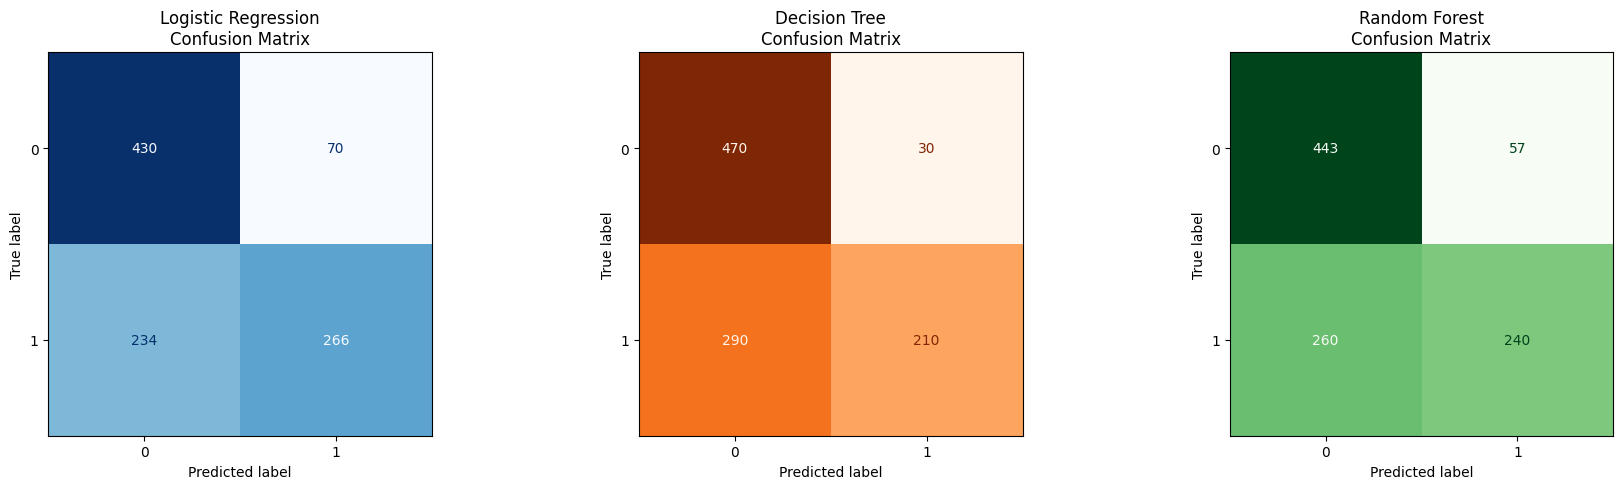

In [ ]:
# Cell 7: Plot side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Logistic Regression
ConfusionMatrixDisplay.from_estimator(
    lr_model, X_test, y_test, ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title("Logistic Regression\nConfusion Matrix")

# 2. Decision Tree
ConfusionMatrixDisplay.from_estimator(
    dt_model, X_test, y_test, ax=axes[1], cmap='Oranges', colorbar=False
)
axes[1].set_title("Decision Tree\nConfusion Matrix")

# 3. Random Forest
ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test, ax=axes[2], cmap='Greens', colorbar=False
)
axes[2].set_title("Random Forest\nConfusion Matrix")

plt.tight_layout()
plt.show()

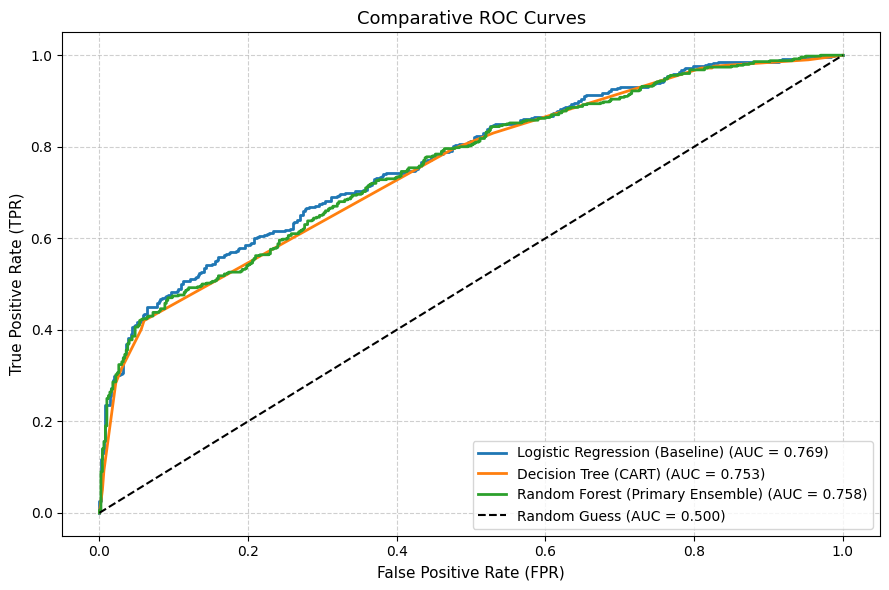

In [ ]:
# Cell 8: Plot comparative ROC Curves
plt.figure(figsize=(9, 6))

for name, (clf, _) in models.items():
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", lw=2)

# Random baseline diagonal
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.500)", lw=1.5)

plt.xlabel("False Positive Rate (FPR)", fontsize=11)
plt.ylabel("True Positive Rate (TPR)", fontsize=11)
plt.title("Comparative ROC Curves", fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('ROC_Comparision.png', dpi=300)
plt.show()

TOP 10 FEATURE IMPORTANCES (RANDOM FOREST)
cat__Platform_TikTok        0.2618
num__Content_Length         0.1582
cat__Platform_LinkedIn      0.0914
cat__Platform_YouTube       0.0724
cat__Content_Type_Stitch    0.0558
cat__Content_Type_Duet      0.0523
cat__Platform_Twitter       0.0353
cat__Content_Type_Poll      0.0223
cat__Content_Type_Video     0.0218
cat__Time_Period_Night      0.0176
dtype: float64


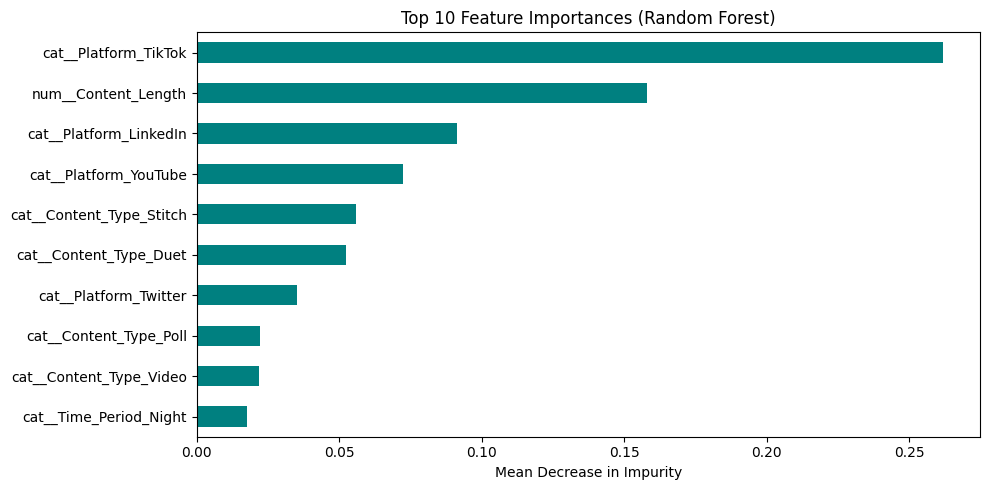

In [ ]:
# Cell 9: Extract and plot top 10 influential predictors

# Get trained Random Forest from Pipeline
rf_classifier = rf_model.named_steps['model']

# Get feature names after preprocessing
feature_names = rf_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Create importance table
importances = pd.Series(
    rf_classifier.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("=" * 60)
print("TOP 10 FEATURE IMPORTANCES (RANDOM FOREST)")
print("=" * 60)
print(importances.head(10).round(4))

# Plot
plt.figure(figsize=(10, 5))
importances.head(10).plot(kind='barh', color='teal')
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Mean Decrease in Impurity")

plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=300)
plt.show()

# **Data Visualzation with Target**

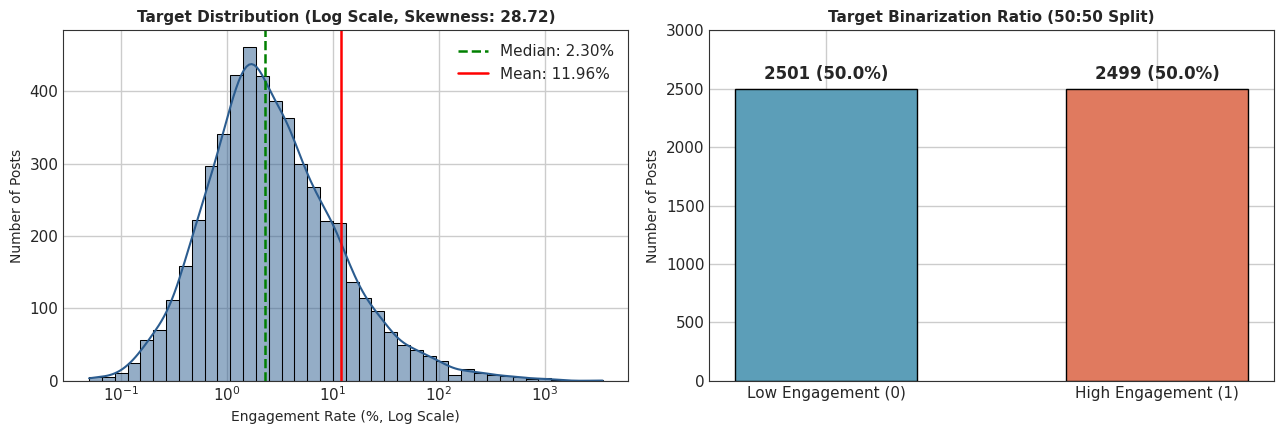

/tmp/ipykernel_1465/4080748247.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


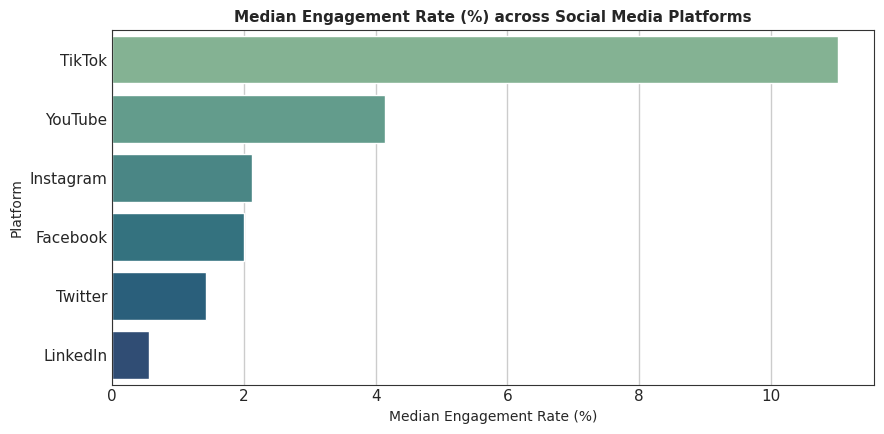

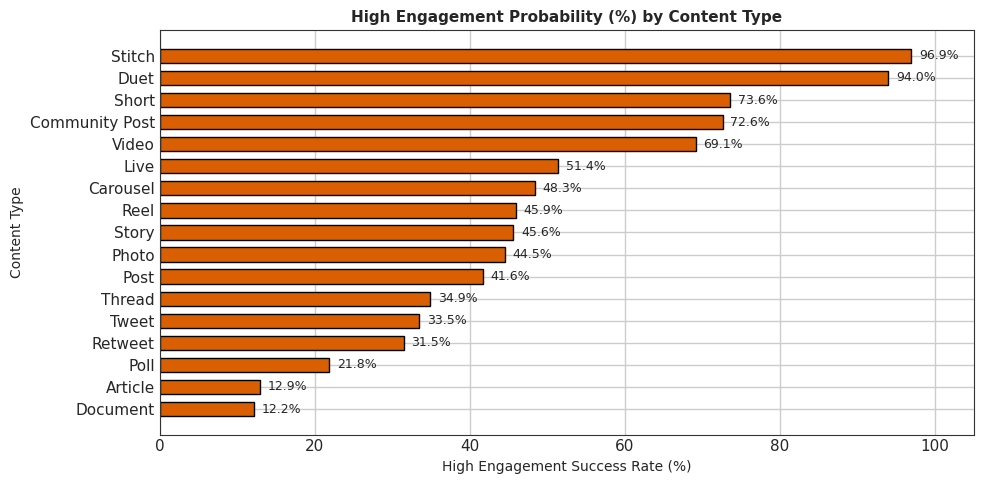

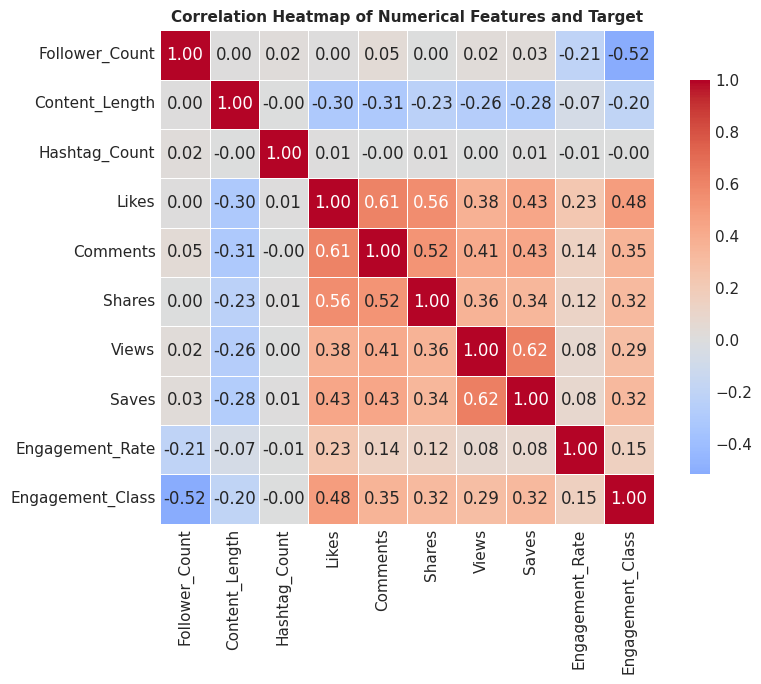

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaned dataset ကို ဖတ်ယူခြင်း
df = pd.read_csv('new_social_media_engagement_cleaned.csv')

# Global Plot Formatting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# ==============================================================================
# Target Distribution & Transformation
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left Plot: Log-Scale Continuous Target Distribution ---
sns.histplot(
    df['Engagement_Rate'],
    bins=40,
    kde=True,
    color='#2b5c8f',
    log_scale=True,
    ax=axes[0],
    edgecolor='black'
)
median_val = df['Engagement_Rate'].median()
mean_val = df['Engagement_Rate'].mean()

axes[0].axvline(median_val, color='green', linestyle='--', linewidth=1.8, label=f'Median: {median_val:.2f}%')
axes[0].axvline(mean_val, color='red', linestyle='-', linewidth=1.8, label=f'Mean: {mean_val:.2f}%')
axes[0].set_title(f"Target Distribution (Log Scale, Skewness: {df['Engagement_Rate'].skew():.2f})", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Engagement Rate (%, Log Scale)", fontsize=10)
axes[0].set_ylabel("Number of Posts", fontsize=10)
axes[0].legend(loc='upper right')

# --- Right Plot: Balanced Binary Target Classes ---
target_counts = df['Engagement_Class'].value_counts()
bars = axes[1].bar(['Low Engagement (0)', 'High Engagement (1)'], target_counts.values, color=['#5c9eb8', '#e07a5f'], edgecolor='black', width=0.55)
axes[1].set_title("Target Binarization Ratio (50:50 Split)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Number of Posts", fontsize=10)
axes[1].set_ylim(0, 3000)
for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 50, f"{yval} ({yval/len(df)*100:.1f}%)", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('Fig_2_3_1_Target_Distribution_Transformation.png', dpi=300)
plt.show()

# ==============================================================================
# Median Engagement Rate by Platform
# ==============================================================================
plt.figure(figsize=(9, 4.5))
platform_order = df.groupby('Platform')['Engagement_Rate'].median().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x='Engagement_Rate',
    y='Platform',
    order=platform_order,
    estimator=np.median,
    errorbar=None,
    palette='crest'
)
plt.title("Median Engagement Rate (%) across Social Media Platforms", fontsize=11, fontweight='bold')
plt.xlabel("Median Engagement Rate (%)", fontsize=10)
plt.ylabel("Platform", fontsize=10)
plt.tight_layout()
plt.savefig('Fig_2_3_2_Platform_Median_Engagement.png', dpi=300)
plt.show()

# ==============================================================================
# High Engagement Probability by Content Format
# ==============================================================================
plt.figure(figsize=(10, 5))
type_risk = (df.groupby('Content_Type')['Engagement_Class'].mean() * 100).sort_values(ascending=True)

bars = plt.barh(type_risk.index, type_risk.values, color='#d95f02', edgecolor='black', height=0.65)
plt.title("High Engagement Probability (%) by Content Type", fontsize=11, fontweight='bold')
plt.xlabel("High Engagement Success Rate (%)", fontsize=10)
plt.ylabel("Content Type", fontsize=10)
plt.xlim(0, 105)

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 1, bar.get_y() + bar.get_height()/2.0, f"{xval:.1f}%", ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('Fig_2_3_3_ContentType_Success_Rate.png', dpi=300)
plt.show()

# ==============================================================================
# Correlation Heatmap of Features with Target
# ==============================================================================
plt.figure(figsize=(9, 7))
num_cols = ['Follower_Count', 'Content_Length', 'Hashtag_Count', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Engagement_Rate', 'Engagement_Class']
corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numerical Features and Target", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('Fig_2_3_5_Correlation_Heatmap.png', dpi=300)
plt.show()

# **For Backend Files**

In [11]:
import joblib

joblib.dump(lr_model, 'logistic_regression_model.joblib')
joblib.dump(dt_model, 'decision_tree_model.joblib')
joblib.dump(rf_model, 'random_forest_model.joblib')

print("All 3 models saved successfully!")

All 3 models saved successfully!


In [14]:
import joblib

joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(dt_model, 'decision_tree_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

print("All 3 PKL models saved successfully!")

All 3 PKL models saved successfully!
